<a href="https://colab.research.google.com/github/abhirules27/ML-Proj-1-Logistic_Regression/blob/From_Google_Colab/Y13_End_to_End_Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing Libraries

import numpy as np
import pandas as pd

In [ ]:
# Imported CSV file from Laptop

df = pd.read_csv('/content/placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
# Checking shape of DataFrame

df.shape

(100, 4)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Steps
0. Preprocess + EDA + Feature Selection.
1. Extract input and output colns.
2. Scale the Values.
3. Train test split.
4. Train the Model.
5. Evaluate the Model/ Model Selection.
6. Deploy the Model.

In [ ]:
# Checking info about each Columns - to check any NULLs

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
# df.iloc[row_indexer, col_indexer] is integer-position indexing in pandas.
# : (before the comma) means all rows.
# : (after the comma) means columns from position 1 to the end (i.e., drop the first column at position 0).

df = df.iloc[:,1:]

In [ ]:
# Taking data preview again

df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
# EDA

import matplotlib.pyplot as plt

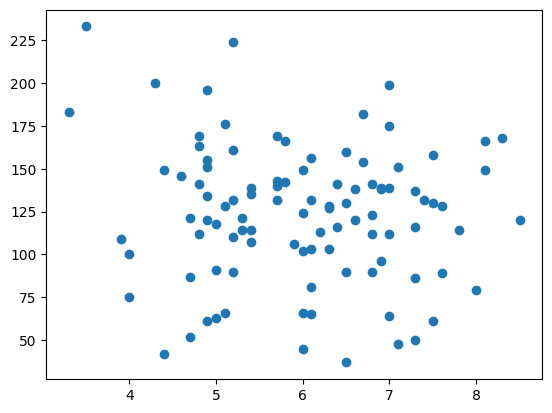

In [ ]:
# Plotting CGPA vs IQ of Students in Class

plt.scatter(df['cgpa'], df['iq'])

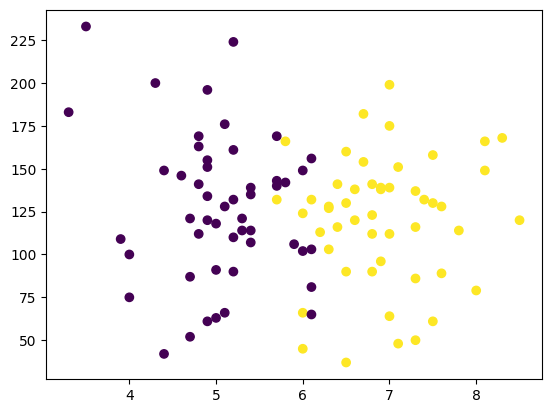

In [ ]:
# Giving color to those Student Values who have been placed

plt.scatter(df['cgpa'], df['iq'],c= df['placement'])

In [ ]:
# Now, we want to make a ML model which will understand this pattern
# Using Logistic Regression - It cuts Data into two if plot can visually be separated in two parts
# Here, two parts are Blue vs Yellow
# Read Logistic Regression from Playlist

In [ ]:
# ML has Dependent and Independent Variables
# Making Dependent Variables

X = df.iloc[:,0:2]  # This is Dependent Variable (All Rows of Coln 0 to 2)
y = df.iloc[:,-1]   # This is Independent Variable (All Rows of Last Coln)

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y.shape

(100,)

In [ ]:
# Step 3: Train test Split (Doing Step 3 before 2)

from sklearn.model_selection import train_test_split

train_test_split(X, y, test_size=0.1) # 0.1 means 10% of my data goes for Test, 90% goes for Training

# This will divide data in 4 part (2 from each X & y)

[    cgpa     iq
 92   5.2  110.0
 8    6.1  156.0
 43   6.8  141.0
 7    5.0   63.0
 89   4.9  151.0
 ..   ...    ...
 14   6.1  103.0
 97   6.7  182.0
 17   3.3  183.0
 33   6.0  149.0
 70   6.3  127.0
 
 [90 rows x 2 columns],
     cgpa     iq
 44   7.5   61.0
 46   5.3  114.0
 94   4.7   52.0
 60   6.9  139.0
 32   7.0  139.0
 56   6.1   65.0
 69   8.5  120.0
 67   5.0  118.0
 25   5.0   91.0
 68   4.0   75.0,
 92    0
 8     0
 43    1
 7     0
 89    0
      ..
 14    0
 97    1
 17    0
 33    0
 70    1
 Name: placement, Length: 90, dtype: int64,
 44    1
 46    0
 94    0
 60    1
 32    1
 56    0
 69    1
 67    0
 25    0
 68    0
 Name: placement, dtype: int64]

In [ ]:
# Storing these data in four variables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [ ]:
X_train

,cgpa,iq
80,4.9,196.0
67,5.0,118.0
11,6.9,138.0
42,7.6,89.0
87,5.7,132.0
...,...,...
9,5.1,66.0
7,5.0,63.0
31,3.9,109.0
27,6.0,124.0


In [ ]:
y_train

,placement
80,0
67,0
11,1
42,1
87,1
...,...
9,0
7,0
31,0
27,1


In [ ]:
X_test

,cgpa,iq
50,3.5,233.0
95,4.3,200.0
79,6.5,90.0
65,8.1,166.0
72,7.3,116.0
40,4.9,134.0
92,5.2,110.0
4,5.8,142.0
22,4.9,120.0
39,4.6,146.0


In [ ]:
y_test

,placement
50,0
95,0
79,1
65,1
72,1
40,0
92,0
4,0
22,0
39,0


In [ ]:
# Now, we have to scale these values from -1 to 1 (Not always reqd)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)

In [ ]:
X_train

array([[-1.04106281,  1.92998169],
       [-0.95009616, -0.08047557],
       [ 0.77827026,  0.43502629],
       [ 1.41503683, -0.82795327],
       [-0.31332958,  0.28037573],
       [-1.04106281, -1.54965587],
       [ 0.5053703 ,  0.43502629],
       [-0.76816285,  2.65168429],
       [-0.58622955,  0.46080139],
       [-0.58622955, -0.18357594],
       [-1.13202947,  0.51235157],
       [ 1.14213687,  0.4092512 ],
       [-1.22299612, -1.78163171],
       [ 0.6873036 ,  0.51235157],
       [-1.49589608,  0.71855232],
       [ 0.59633695,  0.84742778],
       [ 2.23373672, -0.02892538],
       [-0.95009616, -0.77640308],
       [ 0.86923691, -1.47233059],
       [ 0.6873036 , -0.23512613],
       [ 0.41440364,  0.22882555],
       [-1.13202947,  1.23405418],
       [ 0.05053703,  0.89897797],
       [-0.22236293,  1.1567289 ],
       [-1.22299612, -0.00315029],
       [-0.31332958,  0.48657648],
       [ 0.86923691,  0.46080139],
       [ 1.59697014, -0.18357594],
       [ 0.77827026,

In [ ]:
X_test = scaler.transform(X_test)

In [ ]:
X_test

array([[-2.31459596,  2.88366013],
       [-1.58686273,  2.03308206],
       [ 0.41440364, -0.80217817],
       [ 1.8698701 ,  1.1567289 ],
       [ 1.14213687, -0.13202575],
       [-1.04106281,  0.33192592],
       [-0.76816285, -0.28667631],
       [-0.22236293,  0.53812666],
       [-1.04106281, -0.02892538],
       [-1.31396277,  0.64122704]])

In [ ]:
# Training the Model using Logistic regression classifier

from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
# This is Model training

clf.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Model Evaluation - Finding out accuracy using Test Data
# That is, we use model to predict output of 10% data and then compare it with actual data
# This is interesting

y_pred = clf.predict(X_test)

In [ ]:
y_test

,placement
50,0
95,0
79,1
65,1
72,1
40,0
92,0
4,0
22,0
39,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
# accuracy learn compares (Orig Data, Predicted Data) and tells accuracy score
accuracy_score(y_test, y_pred)

1.0

<Axes: >

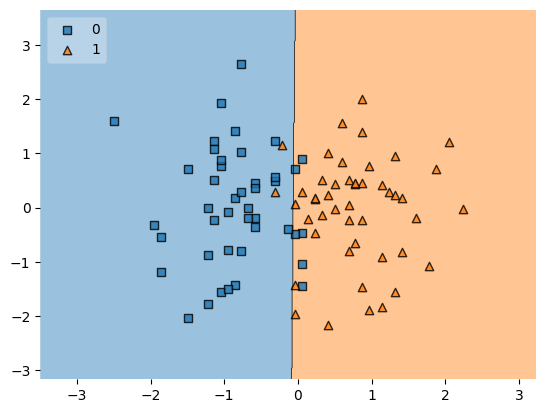

In [ ]:
# Plotting the Decision Boundary (It is the pattern seen in your model by ML)
# Use=ing Library mlxtend

from mlxtend.plotting import plot_decision_regions
# Use following code
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2) # Converted y_train in NumPy Array by using .values

In [ ]:
# Picking up the model
# Use Pickle Library. It converts all Objects in a File

import pickle
pickle.dump(clf, open('model.pkl', 'wb'))

In [ ]:
# Use this Model.pkl which can be deployed in a Website
# Input IQ and CGPA of Student on that Website and it will predict placement status!

In [ ]:
# Use Heroku (5 Applns can be freely hosted), AWS (1 yr - No fees), GCP (Google Cloud Platform)